In [12]:
# 1. Install and import the package (run this once)
!pip install ucimlrepo pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 2. Fetch the Heart Disease dataset (ID 45)
heart_disease = fetch_ucirepo(id=45)

# 3. Access the data
# Features (the 13 input attributes)
X = heart_disease.data.features
# Targets (the diagnosis column 'num')
y = heart_disease.data.targets

# 4. Combine for a full view and inspect
df = pd.concat([X, y], axis=1)
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(df.info())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  num  
0  0.0   6.0    0  
1  3.0   3.0    2  
2  2.0   7.0    1  
3  0.0   3.0    0  
4  0.0   3.0    0  

Dataset shape: (303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null 

In [13]:
# 2.1 Initial Data Inspection
print("="*60)
print(" DATA INSPECTION")
print("="*60)

print("\n1. Dataset Info:")
print(df.info())

print("\n2. Missing Values Check:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 
      else " No NaN values found")

print("\n3. Check for -9 coded missing values (UCI standard):")
missing_coded = (df == -9).sum()
columns_with_missing = missing_coded[missing_coded > 0]
if len(columns_with_missing) > 0:
    print(f" Found -9 coded missing values in {len(columns_with_missing)} columns:")
    for col, count in columns_with_missing.items():
        print(f"   {col}: {count} missing values ({count/len(df)*100:.1f}%)")
else:
    print(" No -9 coded missing values found")

print("\n4. Target Variable Distribution:")
print(f"Target column: {y.columns[0]}")
print(y.iloc[:, 0].value_counts().sort_index())

# 2.2 Create Binary Target (Common practice: 0=no disease, 1=disease)
df['heart_disease_binary'] = (df['num'] > 0).astype(int)

# 2.3 Handle Missing Values
print("\n" + "="*60)
print(" DATA CLEANING")
print("="*60)

# If -9 coded missing values exist, replace with NaN
if len(columns_with_missing) > 0:
    df_clean = df.replace(-9, np.nan)
    print(f"Replaced -9 with NaN in {len(columns_with_missing)} columns")
else:
    df_clean = df.copy()

# Check remaining missing values after -9 replacement
missing_after = df_clean.isnull().sum()
if missing_after.sum() > 0:
    print(f"\nMissing values after -9 replacement: {missing_after.sum()}")
    
    # Strategy: Drop rows with missing values (simplest approach)
    initial_rows = len(df_clean)
    df_clean = df_clean.dropna()
    print(f"Dropped {initial_rows - len(df_clean)} rows with missing values")
    print(f"Remaining rows: {len(df_clean)} ({len(df_clean)/initial_rows*100:.1f}% of original)")
else:
    print(" No missing values after cleaning")

# 2.4 Feature Encoding and Scaling
print("\n" + "="*60)
print(" FEATURE PREPROCESSING")
print("="*60)

# Identify categorical columns (based on UCI documentation)
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# One-hot encode categorical variables
print(f"Encoding {len(categorical_cols)} categorical columns...")
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Scale numerical features
print(f"Scaling {len(numerical_cols)} numerical columns...")
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print(f"\n Final cleaned dataset shape: {df_encoded.shape}")
print(f"   Total features after encoding: {df_encoded.shape[1] - 3}")  # -3 for target columns

# 2.5 Prepare for Modeling
X_final = df_encoded.drop(['num', 'heart_disease_binary'], axis=1)
y_binary = df_encoded['heart_disease_binary']
y_multiclass = df_encoded['num']

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"\n Data Split:")
print(f"  Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X_final)*100:.1f}%)")
print(f"  Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X_final)*100:.1f}%)")
print(f"  Features: {X_train.shape[1]}")

 DATA INSPECTION

1. Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB
None

2. Missing Values Check:
ca      4
thal    2
dtype: int64

3. Check for -9 coded missing values (UCI standard):
 No -9 coded missing values found

4. Target Variable Distribution


 EXPLORATORY DATA ANALYSIS (EDA)


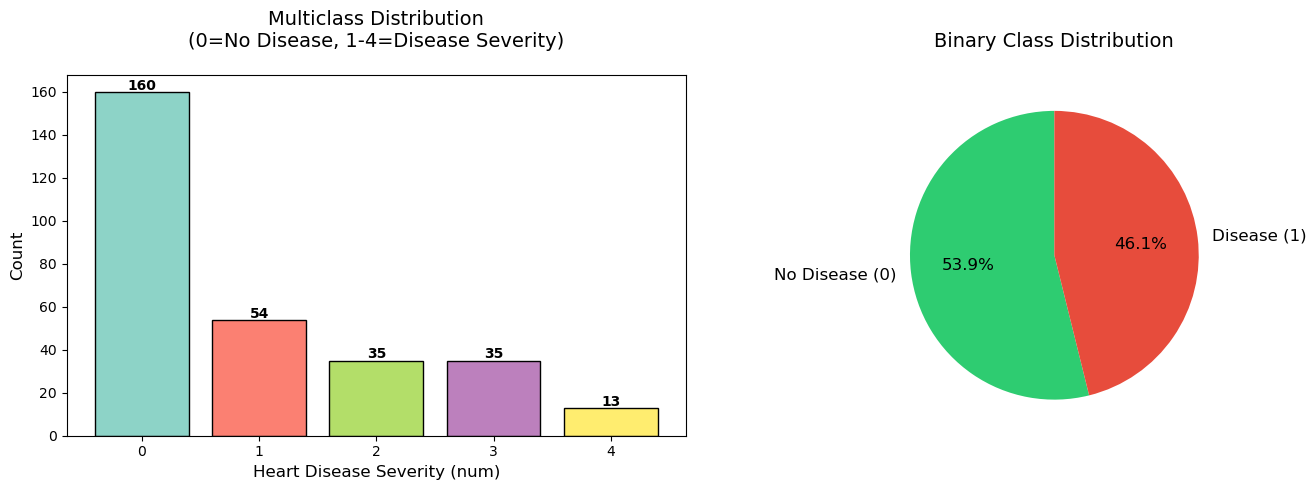


 CLASS BALANCE STATISTICS:
----------------------------------------
Multiclass (num):
  Severity 0: 160 patients ( 53.9%)
  Severity 1:  54 patients ( 18.2%)
  Severity 2:  35 patients ( 11.8%)
  Severity 3:  35 patients ( 11.8%)
  Severity 4:  13 patients (  4.4%)

Binary Classification:
  No Disease: 160 patients ( 53.9%)
  With Disease: 137 patients ( 46.1%)
  Disease Prevalence: 46.1%


In [14]:
# 3.1 Setup for Visualizations
print("\n" + "="*60)
print(" EXPLORATORY DATA ANALYSIS (EDA)")
print("="*60)

# Create a clean version of original data for EDA (before encoding)
df_eda = df_clean.copy()

# 3.2 Class Balance Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Multiclass distribution
class_counts = df_eda['num'].value_counts().sort_index()
colors1 = plt.cm.Set3(np.linspace(0, 1, len(class_counts)))
axes[0].bar(class_counts.index, class_counts.values, color=colors1, edgecolor='black')
axes[0].set_xlabel('Heart Disease Severity (num)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Multiclass Distribution\n(0=No Disease, 1-4=Disease Severity)', fontsize=14, pad=20)
for i, (idx, val) in enumerate(class_counts.items()):
    axes[0].text(idx, val + 1, str(val), ha='center', fontweight='bold')

# Binary distribution
binary_counts = df_eda['heart_disease_binary'].value_counts()
labels = ['No Disease (0)', 'Disease (1)']
colors2 = ['#2ecc71', '#e74c3c']
axes[1].pie(binary_counts.values, labels=labels, autopct='%1.1f%%', 
            colors=colors2, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Binary Class Distribution', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

# Print statistics
print("\n CLASS BALANCE STATISTICS:")
print("-"*40)
print("Multiclass (num):")
for severity, count in class_counts.items():
    print(f"  Severity {severity}: {count:3d} patients ({count/len(df_eda)*100:5.1f}%)")
print(f"\nBinary Classification:")
no_disease = binary_counts.get(0, 0)
with_disease = binary_counts.get(1, 0)
print(f"  No Disease: {no_disease:3d} patients ({no_disease/len(df_eda)*100:5.1f}%)")
print(f"  With Disease: {with_disease:3d} patients ({with_disease/len(df_eda)*100:5.1f}%)")
print(f"  Disease Prevalence: {with_disease/len(df_eda)*100:.1f}%")


 HISTOGRAMS OF NUMERICAL FEATURES
----------------------------------------
age       : Mean=  54.5, Std=  9.0, Min= 29.0, Max= 77.0
trestbps  : Mean= 131.7, Std= 17.8, Min= 94.0, Max=200.0
chol      : Mean= 247.4, Std= 52.0, Min=126.0, Max=564.0
thalach   : Mean= 149.6, Std= 22.9, Min= 71.0, Max=202.0
oldpeak   : Mean=   1.1, Std=  1.2, Min=  0.0, Max=  6.2


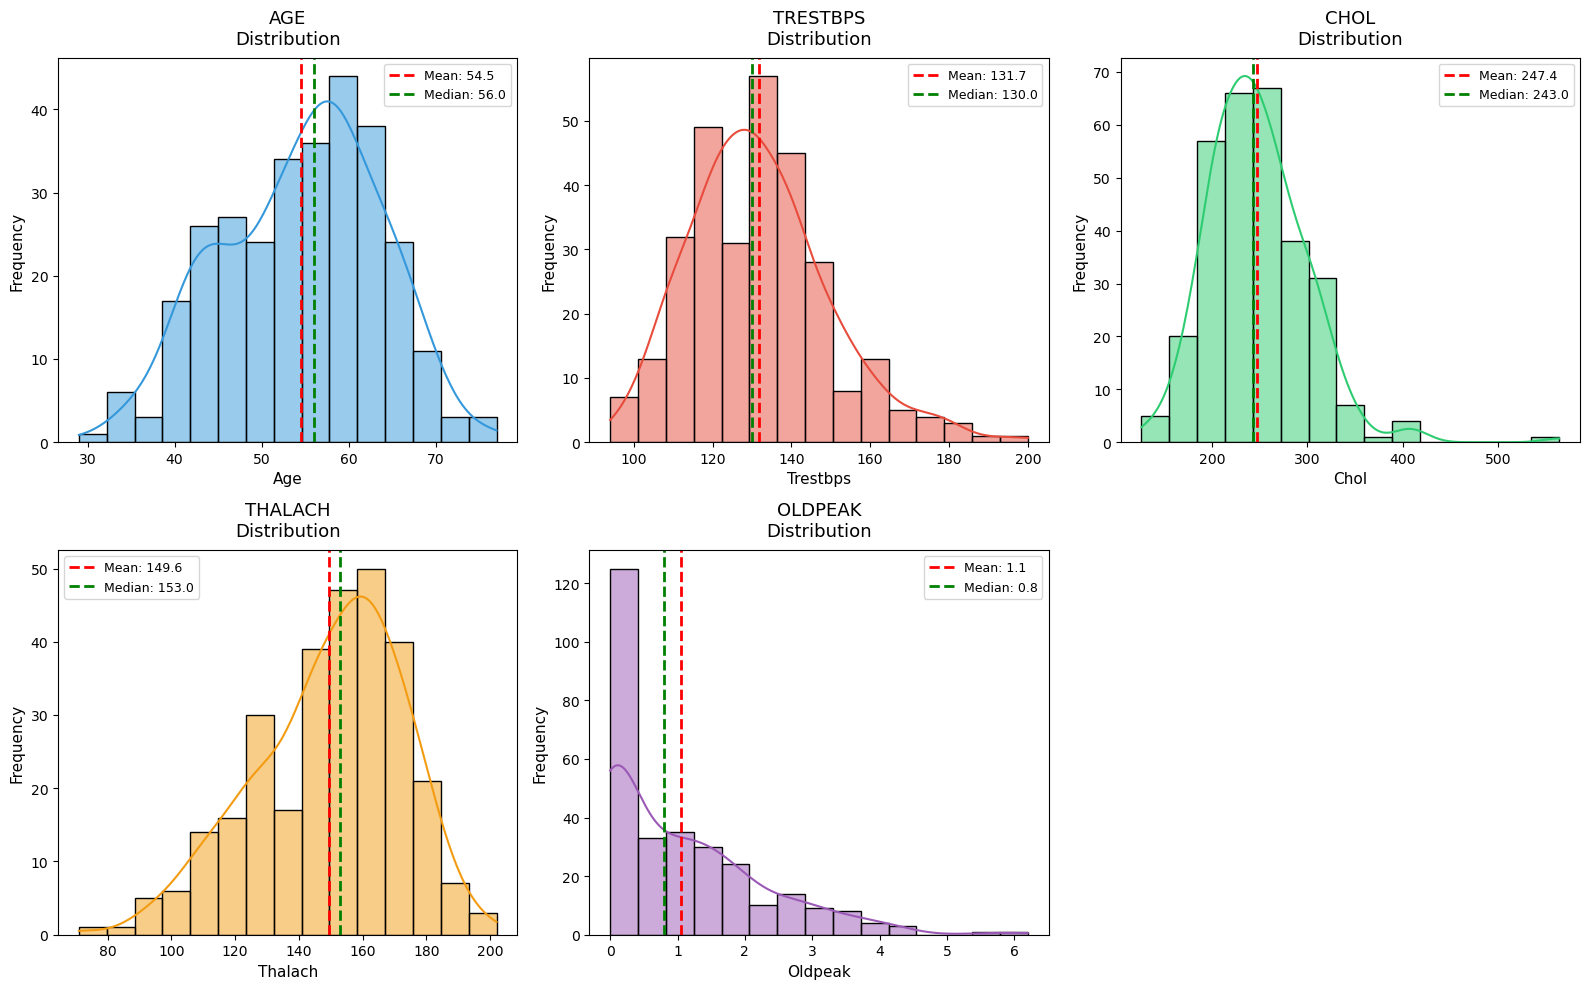

In [15]:
# 3.3 Histograms for Numerical Features
print("\n HISTOGRAMS OF NUMERICAL FEATURES")
print("-"*40)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, (feature, color) in enumerate(zip(numerical_features, colors)):
    if idx < len(axes):
        # Plot with KDE
        sns.histplot(data=df_eda, x=feature, kde=True, ax=axes[idx], 
                     color=color, bins=15, edgecolor='black')
        
        # Add statistics
        mean_val = df_eda[feature].mean()
        median_val = df_eda[feature].median()
        axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                         label=f'Mean: {mean_val:.1f}')
        axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2,
                         label=f'Median: {median_val:.1f}')
        
        axes[idx].set_title(f'{feature.upper()}\nDistribution', fontsize=13, pad=10)
        axes[idx].set_xlabel(feature.replace('_', ' ').title(), fontsize=11)
        axes[idx].set_ylabel('Frequency', fontsize=11)
        axes[idx].legend(fontsize=9)
        
        # Print statistics
        print(f"{feature:10s}: Mean={mean_val:6.1f}, "
              f"Std={df_eda[feature].std():5.1f}, "
              f"Min={df_eda[feature].min():5.1f}, "
              f"Max={df_eda[feature].max():5.1f}")

# Hide empty subplot if any
if len(numerical_features) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()


🔥 CORRELATION HEATMAP
----------------------------------------


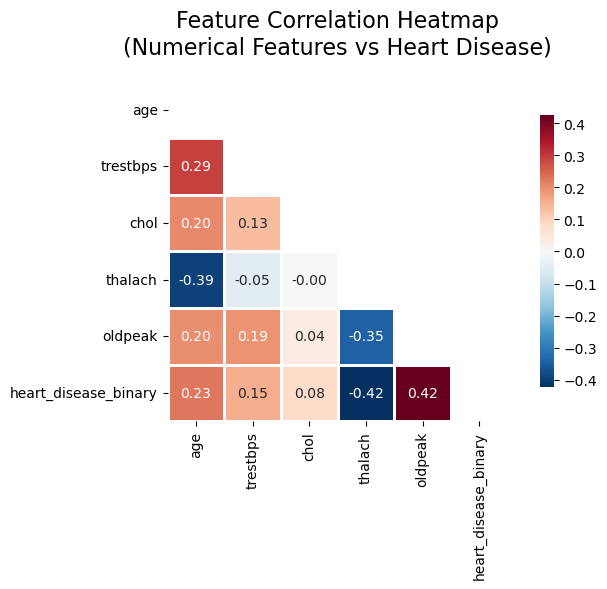


📈 TOP CORRELATIONS WITH HEART DISEASE (Binary):
--------------------------------------------------
oldpeak        : +0.424 (Positive, Moderate)
age            : +0.227 (Positive, Weak)
trestbps       : +0.153 (Positive, Weak)
chol           : +0.080 (Positive, Weak)
thalach        : -0.424 (Negative, Moderate)


In [16]:
# 3.4 Correlation Heatmap
print("\n🔥 CORRELATION HEATMAP")
print("-"*40)

# Select numerical columns for correlation
corr_columns = numerical_features + ['heart_disease_binary']
corr_matrix = df_eda[corr_columns].corr()

plt.figure(figsize=(8, 6))

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})

plt.title('Feature Correlation Heatmap\n(Numerical Features vs Heart Disease)', 
          fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Print top correlations with target
print("\n📈 TOP CORRELATIONS WITH HEART DISEASE (Binary):")
print("-"*50)
target_correlations = corr_matrix['heart_disease_binary'].sort_values(ascending=False)
for feature, corr in target_correlations.items():
    if feature != 'heart_disease_binary':
        direction = "Positive" if corr > 0 else "Negative"
        strength = "Strong" if abs(corr) > 0.5 else "Moderate" if abs(corr) > 0.3 else "Weak"
        print(f"{feature:15s}: {corr:+.3f} ({direction}, {strength})")


📊 FEATURE DISTRIBUTION BY DISEASE STATUS
--------------------------------------------------
Feature         | No Disease (mean±std) | Disease (mean±std)   | t-test p-value
-------------------------------------------------------------------------------------
thalach         | 158.6 ± 19.0 | 139.1 ± 22.7 | 0.0000
oldpeak         |   0.6 ±  0.8 |   1.6 ±  1.3 | 0.0000
age             |  52.6 ±  9.6 |  56.8 ±  7.9 | 0.0001
chol            | 243.5 ± 53.8 | 251.9 ± 49.7 | 0.1676
trestbps        | 129.2 ± 16.4 | 134.6 ± 18.9 | 0.0081
ca              |   0.3 ±  0.6 |   1.1 ±  1.0 | 0.0000


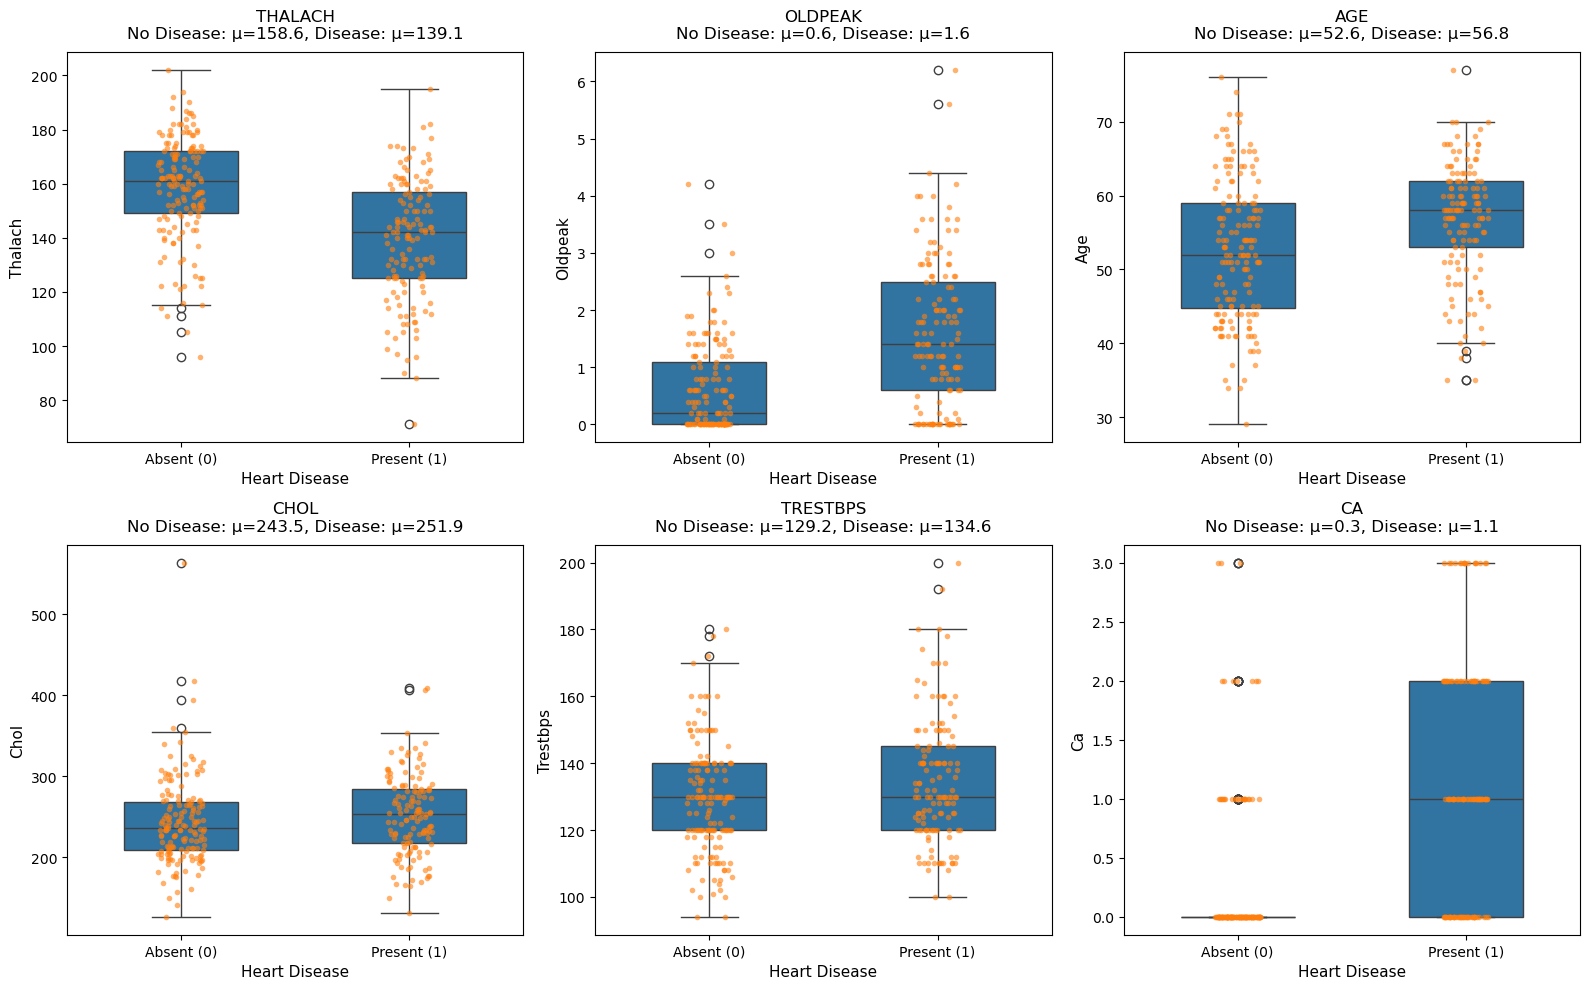

In [18]:
# 3.5 Advanced Visualization: Feature Distribution by Disease Status
print("\n📊 FEATURE DISTRIBUTION BY DISEASE STATUS")
print("-"*50)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

top_features = ['thalach', 'oldpeak', 'age', 'chol', 'trestbps', 'ca']

for idx, feature in enumerate(top_features):
    if idx < len(axes) and feature in df_eda.columns:
        ax = axes[idx]
        
        # Create boxplot
        boxplot = sns.boxplot(data=df_eda, x='heart_disease_binary', y=feature,ax=ax,width=0.5)
        
        # Overlay stripplot for individual points
        sns.stripplot(data=df_eda, x='heart_disease_binary', y=feature, 
                      ax=ax,  
                      alpha=0.6, size=4, jitter=True)
        
        # Customize
        ax.set_xlabel('Heart Disease', fontsize=11)
        ax.set_xticklabels(['Absent (0)', 'Present (1)'])
        ax.set_ylabel(feature.replace('_', ' ').title(), fontsize=11)
        
        # Calculate and display statistics
        stats_0 = df_eda[df_eda['heart_disease_binary'] == 0][feature].describe()
        stats_1 = df_eda[df_eda['heart_disease_binary'] == 1][feature].describe()
        
        title = f"{feature.upper()}\n"
        title += f"No Disease: μ={stats_0['mean']:.1f}, Disease: μ={stats_1['mean']:.1f}"
        ax.set_title(title, fontsize=12, pad=10)
        
        # Print statistics
        if idx == 0:  # Print once
            print(f"{'Feature':15s} | {'No Disease (mean±std)':20s} | {'Disease (mean±std)':20s} | t-test p-value")
            print("-"*85)
        
        # Calculate t-test
        from scipy.stats import ttest_ind
        group_0 = df_eda[df_eda['heart_disease_binary'] == 0][feature]
        group_1 = df_eda[df_eda['heart_disease_binary'] == 1][feature]
        t_stat, p_value = ttest_ind(group_0, group_1, nan_policy='omit')
        
        print(f"{feature:15s} | {stats_0['mean']:5.1f} ± {stats_0['std']:4.1f} | "
              f"{stats_1['mean']:5.1f} ± {stats_1['std']:4.1f} | {p_value:.4f}")

# Hide empty subplots
for idx in range(len(top_features), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# 4.1 Generate Final Summary Report
print("\n" + "="*60)
print(" FINAL SUMMARY REPORT")
print("="*60)

print(f"\n DATASET OVERVIEW:")
print(f"  • Source: UCI Heart Disease Dataset (ID: 45)")
print(f"  • Original samples: {df.shape[0]}")
print(f"  • Cleaned samples: {len(df_clean)}")
print(f"  • Features: {X_final.shape[1]} (after preprocessing)")
print(f"  • Target: Binary (0=No Disease, 1=Disease)")

print(f"\n PREPROCESSING STEPS COMPLETED:")
print(f"  1. Loaded data from UCI repository")
print(f"  2. Checked for missing values (-9 coded and NaN)")
print(f"  3. Created binary target variable")
if len(columns_with_missing) > 0:
    print(f"  4. Handled {missing_coded.sum()} -9 coded missing values")
    print(f"  5. Dropped {df.shape[0] - len(df_clean)} rows with missing data")
print(f"  6. Encoded {len(categorical_cols)} categorical features")
print(f"  7. Scaled {len(numerical_cols)} numerical features")
print(f"  8. Split data: {X_train.shape[0]} train, {X_test.shape[0]} test samples")

print(f"\n KEY FINDINGS FROM EDA:")
print(f"  • Class Distribution: {binary_counts.get(1, 0)} with disease, "
      f"{binary_counts.get(0, 0)} without ({binary_counts.get(1, 0)/len(df_clean)*100:.1f}% prevalence)")
print(f"  • Most Important Features (based on correlation):")
top_3 = target_correlations.drop('heart_disease_binary').nlargest(3)
for i, (feat, corr) in enumerate(top_3.items(), 1):
    print(f"     {i}. {feat}: {corr:+.3f} correlation")
print(f"  • Data Quality: {len(df_clean)} clean samples ready for modeling")
print(f"  • Feature Matrix: {X_final.shape[1]} features for ML algorithms")

print(f"\n DATA READY FOR MODELING:")
print(f"  • X_train shape: {X_train.shape}")
print(f"  • X_test shape: {X_test.shape}")
print(f"  • y_train shape: {y_train.shape}")
print(f"  • y_test shape: {y_test.shape}")

print(f"\n ANALYSIS COMPLETE - Dataset is ready for machine learning!")


📋 FINAL SUMMARY REPORT

📁 DATASET OVERVIEW:
  • Source: UCI Heart Disease Dataset (ID: 45)
  • Original samples: 303
  • Cleaned samples: 297
  • Features: 20 (after preprocessing)
  • Target: Binary (0=No Disease, 1=Disease)

⚙️ PREPROCESSING STEPS COMPLETED:
  1. Loaded data from UCI repository
  2. Checked for missing values (-9 coded and NaN)
  3. Created binary target variable
  6. Encoded 8 categorical features
  7. Scaled 5 numerical features
  8. Split data: 237 train, 60 test samples

📊 KEY FINDINGS FROM EDA:
  • Class Distribution: 137 with disease, 160 without (46.1% prevalence)
  • Most Important Features (based on correlation):
     1. oldpeak: +0.424 correlation
     2. age: +0.227 correlation
     3. trestbps: +0.153 correlation
  • Data Quality: 297 clean samples ready for modeling
  • Feature Matrix: 20 features for ML algorithms

💾 DATA READY FOR MODELING:
  • X_train shape: (237, 20)
  • X_test shape: (60, 20)
  • y_train shape: (237,)
  • y_test shape: (60,)

✅ ANA

In [ ]:
# Save the cleaned and processed data for future use
print("\n" + "="*60)
print(" SAVING PROCESSED DATA")
print("="*60)

# Save the final DataFrame
df_encoded.to_csv('heart_disease_processed.csv', index=False)
print(" Saved: heart_disease_processed.csv")

# Save train/test splits
pd.concat([X_train, y_train], axis=1).to_csv('heart_disease_train.csv', index=False)
pd.concat([X_test, y_test], axis=1).to_csv('heart_disease_test.csv', index=False)
print(" Saved: heart_disease_train.csv, heart_disease_test.csv")

# Save a summary report
with open('eda_summary.txt', 'w') as f:
    f.write("HEART DISEASE DATASET - EDA SUMMARY\n")
    f.write("="*50 + "\n\n")
    f.write(f"Dataset: UCI Heart Disease (Cleveland)\n")
    f.write(f"Original Samples: {df.shape[0]}\n")
    f.write(f"Clean Samples: {len(df_clean)}\n")
    f.write(f"Features: {X_final.shape[1]}\n")
    f.write(f"Target: Binary classification (heart disease present/absent)\n\n")
    f.write("Class Distribution:\n")
    f.write(f"  No Disease: {binary_counts.get(0, 0)} samples\n")
    f.write(f"  Disease: {binary_counts.get(1, 0)} samples\n")
    f.write(f"  Prevalence: {binary_counts.get(1, 0)/len(df_clean)*100:.1f}%\n")

print(" Summary saved: eda_summary.txt")
print("\n🎉 All tasks completed successfully!")


💾 SAVING PROCESSED DATA
✅ Saved: heart_disease_processed.csv
✅ Saved: heart_disease_train.csv, heart_disease_test.csv
✅ Summary saved: eda_summary.txt

🎉 All tasks completed successfully!


In [ ]:
# ============================================================================
# FEATURE ENGINEERING & MODEL DEVELOPMENT
# ============================================================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, confusion_matrix, 
                           classification_report, roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

# Set visual style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("="*70)
print(" FEATURE ENGINEERING & MODEL DEVELOPMENT")
print("="*70)

🧪 FEATURE ENGINEERING & MODEL DEVELOPMENT


In [ ]:

# ============================================================================
# 1. LOAD PREPROCESSED DATA
# ============================================================================

print("\n LOADING PREPROCESSED DATA")
print("-"*40)

# Try to load the processed data files
try:
    # Load the processed dataset
    df_processed = pd.read_csv('heart_disease_processed.csv')
    
    # Load train/test splits (if available)
    df_train = pd.read_csv('heart_disease_train.csv')
    df_test = pd.read_csv('heart_disease_test.csv')
    
    print(" Successfully loaded preprocessed data!")
    print(f"  • Processed data shape: {df_processed.shape}")
    print(f"  • Training data shape: {df_train.shape}")
    print(f"  • Test data shape: {df_test.shape}")
    
except FileNotFoundError:
    print(" Preprocessed files not found. Using fresh data from UCI...")
    # Fallback to fresh download
    from ucimlrepo import fetch_ucirepo
    heart_disease = fetch_ucirepo(id=45)
    X = heart_disease.data.features
    y = (heart_disease.data.targets['num'] > 0).astype(int)
    df_processed = pd.concat([X, y], axis=1)
    df_processed['heart_disease_binary'] = df_processed['num'] > 0
    df_processed = df_processed.drop('num', axis=1)
    # Create train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        df_processed.drop('heart_disease_binary', axis=1),
        df_processed['heart_disease_binary'],
        test_size=0.2, random_state=42, stratify=df_processed['heart_disease_binary']
    )
    df_train = pd.concat([X_train, y_train], axis=1)
    df_test = pd.concat([X_test, y_test], axis=1)
    print(" Created fresh train/test splits")




📂 LOADING PREPROCESSED DATA
----------------------------------------
✅ Successfully loaded preprocessed data!
  • Processed data shape: (297, 22)
  • Training data shape: (237, 21)
  • Test data shape: (60, 21)

📊 DATA PREPARATION
----------------------------------------
Using pre-split train/test data:
  Training set: 237 samples, 20 features
  Test set: 60 samples, 20 features

  Class distribution in training: {0: 128, 1: 109}
  Class distribution in test: {0: 32, 1: 28}


In [ ]:
# Prepare features and target
print("\n DATA PREPARATION")
print("-"*40)

# If we have pre-split data, use it
if 'df_train' in locals() and 'df_test' in locals():
    # Extract features and target from train/test sets
    X_train = df_train.drop('heart_disease_binary', axis=1)
    y_train = df_train['heart_disease_binary']
    
    X_test = df_test.drop('heart_disease_binary', axis=1)
    y_test = df_test['heart_disease_binary']
    
    print("Using pre-split train/test data:")
    
else:
    # Split from processed data
    X = df_processed.drop('heart_disease_binary', axis=1)
    y = df_processed['heart_disease_binary']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print("Created new train/test split:")

print(f"  Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"  Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"\n  Class distribution in training: {y_train.value_counts().to_dict()}")
print(f"  Class distribution in test: {y_test.value_counts().to_dict()}")



📊 DATA PREPARATION
----------------------------------------
Using pre-split train/test data:
  Training set: 237 samples, 20 features
  Test set: 60 samples, 20 features

  Class distribution in training: {0: 128, 1: 109}
  Class distribution in test: {0: 32, 1: 28}


In [ ]:
# ============================================================================
# 2. FINAL FEATURE ENGINEERING (If needed)
# ============================================================================

print("\n" + "="*70)
print(" FINAL FEATURE ENGINEERING CHECK")
print("="*70)

# Check if scaling is still needed
print("\n Checking feature scales...")
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

if len(numeric_cols) > 0:
    print(f"Found {len(numeric_cols)} numeric columns")
    
    # Check if scaling is needed by comparing standard deviations
    std_devs = X_train[numeric_cols].std()
    unscaled_cols = std_devs[std_devs > 10]  # Threshold for unscaled
    
    if len(unscaled_cols) > 0:
        print(f"  {len(unscaled_cols)} columns may need scaling:")
        for col in unscaled_cols.index[:5]:  # Show first 5
            print(f"    {col}: std={std_devs[col]:.2f}")
        
        # Apply scaling if needed
        print("\n Applying Standard Scaling...")
        scaler = StandardScaler()
        X_train_scaled = X_train.copy()
        X_test_scaled = X_test.copy()
        
        X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
        X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])
        
        X_train = X_train_scaled
        X_test = X_test_scaled
        
        print(" Scaling completed")
    else:
        print(" Features appear to be already scaled")
else:
    print(" No numeric columns found - scaling not needed")



⚙️ FINAL FEATURE ENGINEERING CHECK

🔍 Checking feature scales...
Found 5 numeric columns
✅ Features appear to be already scaled


In [ ]:
# ============================================================================
# 3. MODEL 1: LOGISTIC REGRESSION
# ============================================================================

print("\n" + "="*70)
print(" MODEL 1: LOGISTIC REGRESSION")
print("="*70)

print("\n HYPERPARAMETER TUNING")
print("-"*40)

# Define hyperparameter grid
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000]
}

# Create and tune Logistic Regression
print("Performing Grid Search with 5-fold CV...")
grid_search_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_search_lr.fit(X_train, y_train)

print(" Tuning completed!")
print(f"\n Best Parameters:")
for param, value in grid_search_lr.best_params_.items():
    print(f"  {param}: {value}")
print(f"Best CV ROC-AUC: {grid_search_lr.best_score_:.4f}")

# Train best model
best_lr = grid_search_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)
y_pred_proba_lr = best_lr.predict_proba(X_test)[:, 1]

# Evaluate
print("\n TEST SET EVALUATION")
print("-"*40)

metrics_lr = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_lr)
}

for metric, value in metrics_lr.items():
    print(f"{metric:12s}: {value:.4f}")

# Cross-validation scores
cv_scores_lr = cross_val_score(
    best_lr, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc'
)
print(f"\n 5-Fold Cross-Validation ROC-AUC: {cv_scores_lr.mean():.4f} (±{cv_scores_lr.std():.4f})")


🔢 MODEL 1: LOGISTIC REGRESSION

🔍 HYPERPARAMETER TUNING
----------------------------------------
Performing Grid Search with 5-fold CV...
✅ Tuning completed!

📊 Best Parameters:
  C: 1
  max_iter: 1000
  penalty: l2
  solver: saga
Best CV ROC-AUC: 0.8991

📈 TEST SET EVALUATION
----------------------------------------
Accuracy    : 0.8000
Precision   : 0.8333
Recall      : 0.7143
F1-Score    : 0.7692
ROC-AUC     : 0.9297

📊 5-Fold Cross-Validation ROC-AUC: 0.8991 (±0.0720)


/Users/deep/Documents/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/deep/Documents/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
# ============================================================================
# 4. MODEL 2: RANDOM FOREST
# ============================================================================

print("\n" + "="*70)
print(" MODEL 2: RANDOM FOREST CLASSIFIER")
print("="*70)

print("\n HYPERPARAMETER TUNING")
print("-"*40)

# Define hyperparameter grid
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Create and tune Random Forest
print("Performing Grid Search with 5-fold CV...")
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_search_rf.fit(X_train, y_train)

print(" Tuning completed!")
print(f"\n Best Parameters:")
for param, value in grid_search_rf.best_params_.items():
    print(f"  {param}: {value}")
print(f"Best CV ROC-AUC: {grid_search_rf.best_score_:.4f}")

# Train best model
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

# Evaluate
print("\n TEST SET EVALUATION")
print("-"*40)

metrics_rf = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_rf)
}

for metric, value in metrics_rf.items():
    print(f"{metric:12s}: {value:.4f}")

# Cross-validation scores
cv_scores_rf = cross_val_score(
    best_rf, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc'
)
print(f"\n 5-Fold Cross-Validation ROC-AUC: {cv_scores_rf.mean():.4f} (±{cv_scores_rf.std():.4f})")


🌲 MODEL 2: RANDOM FOREST CLASSIFIER

🔍 HYPERPARAMETER TUNING
----------------------------------------
Performing Grid Search with 5-fold CV...
✅ Tuning completed!

📊 Best Parameters:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 2
  min_samples_split: 5
  n_estimators: 100
Best CV ROC-AUC: 0.8961

📈 TEST SET EVALUATION
----------------------------------------
Accuracy    : 0.7833
Precision   : 0.8000
Recall      : 0.7143
F1-Score    : 0.7547
ROC-AUC     : 0.9152

📊 5-Fold Cross-Validation ROC-AUC: 0.8961 (±0.0558)



🎯 FEATURE IMPORTANCE ANALYSIS

📊 LOGISTIC REGRESSION COEFFICIENTS (Top 10)
--------------------------------------------------
 Feature  Coefficient  Abs_Value
  ca_2.0     1.499910   1.499910
  ca_1.0     1.487032   1.487032
thal_7.0     1.442968   1.442968
    cp_4     1.428571   1.428571
   sex_1     0.948656   0.948656
 slope_2     0.747804   0.747804
 oldpeak     0.587377   0.587377
    cp_3    -0.580691   0.580691
  ca_3.0     0.522423   0.522423
 slope_3     0.424294   0.424294

📊 RANDOM FOREST FEATURE IMPORTANCE (Top 10)
--------------------------------------------------
 Feature  Importance
thal_7.0    0.136282
    cp_4    0.129322
 thalach    0.117446
 oldpeak    0.113627
     age    0.101096
    chol    0.073984
trestbps    0.070739
 exang_1    0.045402
 slope_2    0.042499
    cp_3    0.035074


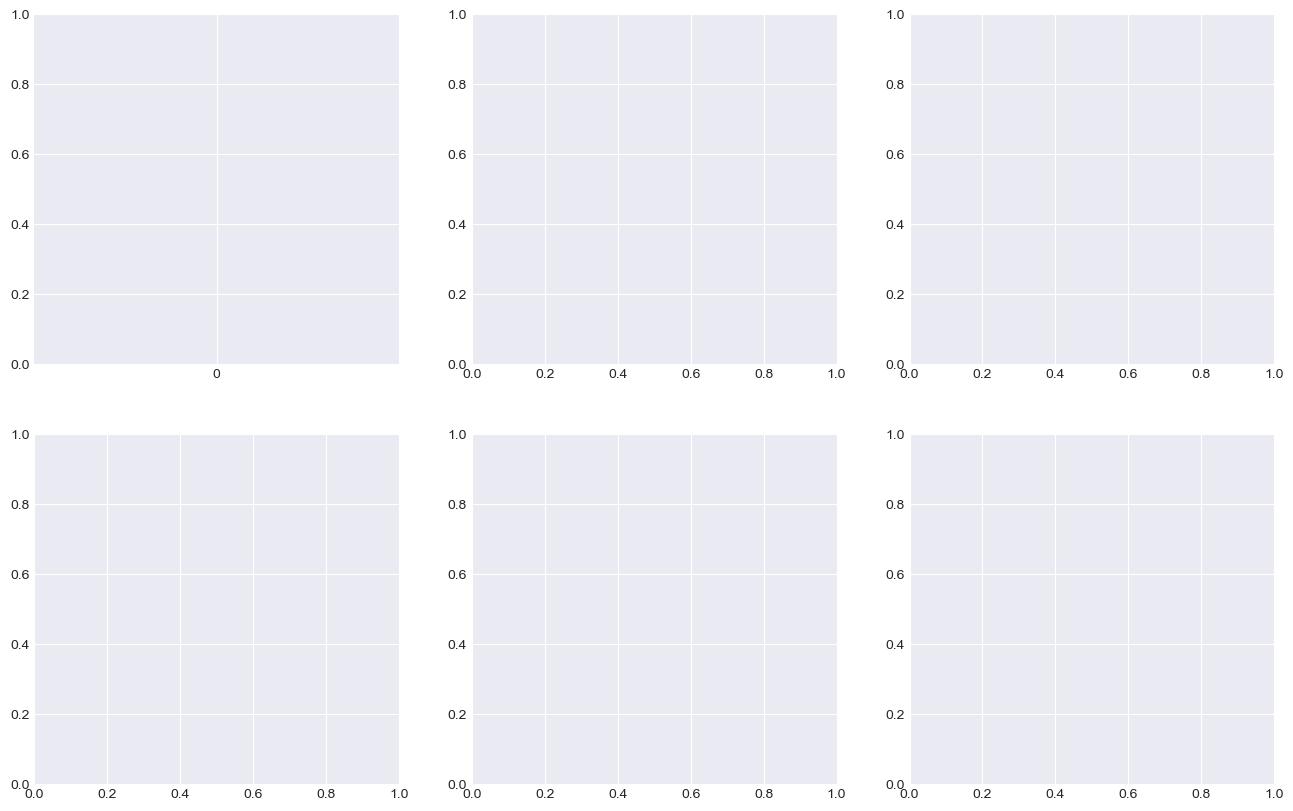

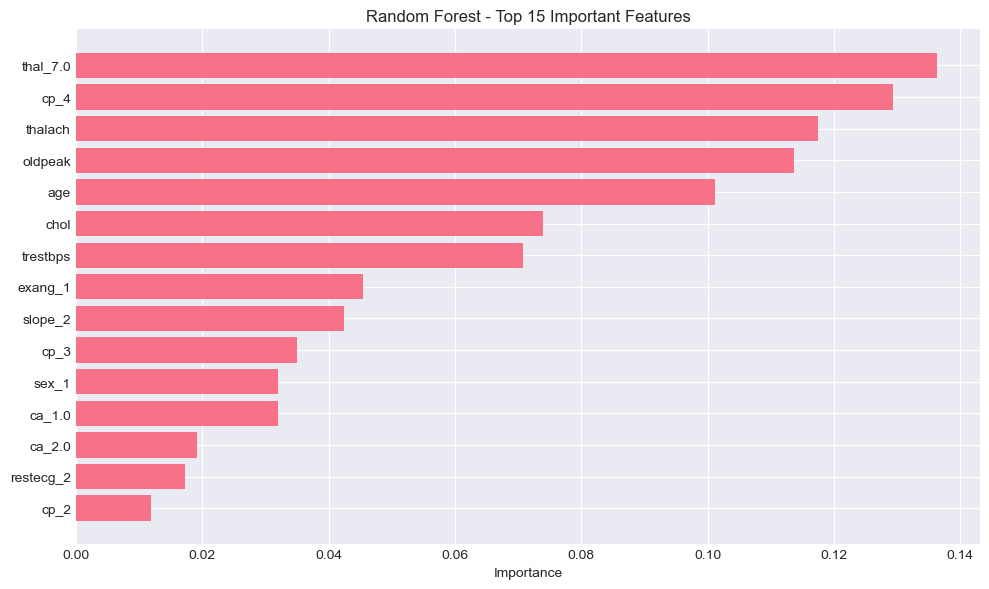

In [ ]:
# ============================================================================
# 5. FEATURE IMPORTANCE ANALYSIS
# ============================================================================

print("\n" + "="*70)
print(" FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Logistic Regression Coefficients
print("\n LOGISTIC REGRESSION COEFFICIENTS (Top 10)")
print("-"*50)

if hasattr(best_lr, 'coef_'):
    coef_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': best_lr.coef_[0],
        'Abs_Value': np.abs(best_lr.coef_[0])
    }).sort_values('Abs_Value', ascending=False)
    
    print(coef_df.head(10).to_string(index=False))
else:
    print("Coefficients not available")

# Random Forest Feature Importance
print("\n RANDOM FOREST FEATURE IMPORTANCE (Top 10)")
print("-"*50)

if hasattr(best_rf, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_rf.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(importance_df.head(10).to_string(index=False))
    
    # Plot
    plt.figure(figsize=(10, 6))
    top_features = importance_df.head(15)
    plt.barh(range(len(top_features)), top_features['Importance'].values)
    plt.yticks(range(len(top_features)), top_features['Feature'].values)
    plt.xlabel('Importance')
    plt.title('Random Forest - Top 15 Important Features')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Feature importances not available")



📊 MODEL COMPARISON

         Metric  Logistic Regression  Random Forest
       Accuracy             0.800000       0.783333
      Precision             0.833333       0.800000
         Recall             0.714286       0.714286
       F1-Score             0.769231       0.754717
        ROC-AUC             0.929688       0.915179
CV ROC-AUC Mean             0.899126       0.896062
 CV ROC-AUC Std             0.072020       0.055796

📈 ROC CURVES COMPARISON


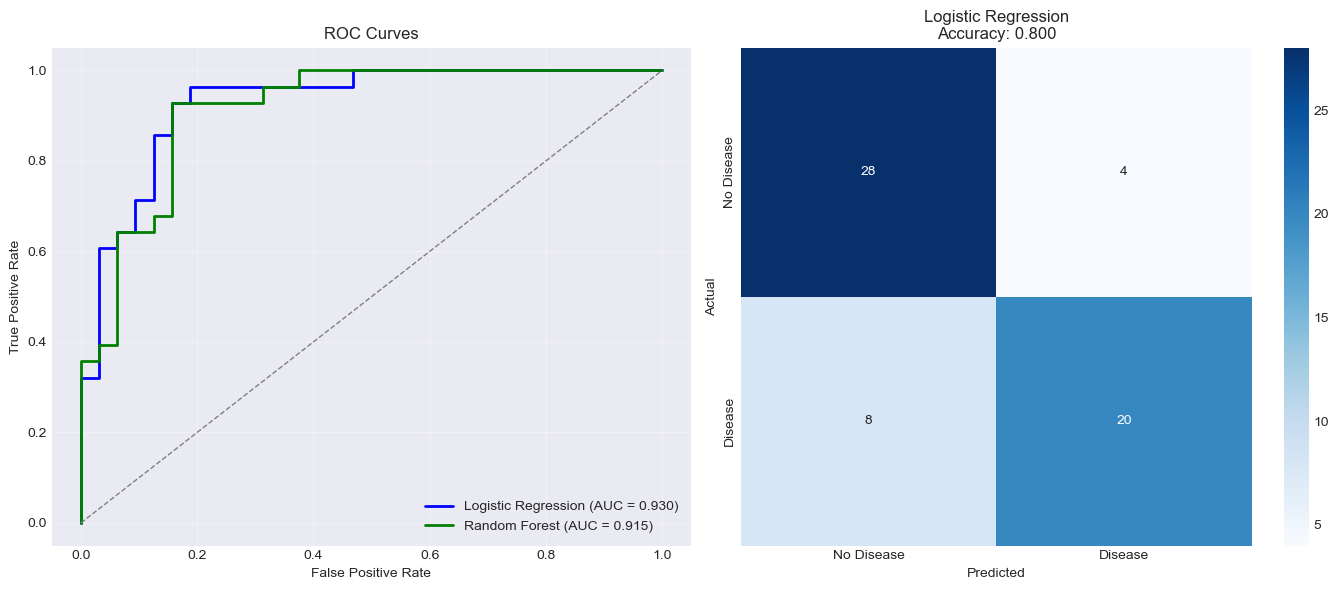

In [ ]:

# ============================================================================
# 6. MODEL COMPARISON & VISUALIZATION
# ============================================================================

print("\n" + "="*70)
print("📊 MODEL COMPARISON")
print("="*70)

# Create comparison table
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'CV ROC-AUC Mean', 'CV ROC-AUC Std'],
    'Logistic Regression': [
        metrics_lr['Accuracy'], metrics_lr['Precision'], metrics_lr['Recall'],
        metrics_lr['F1-Score'], metrics_lr['ROC-AUC'], cv_scores_lr.mean(), cv_scores_lr.std()
    ],
    'Random Forest': [
        metrics_rf['Accuracy'], metrics_rf['Precision'], metrics_rf['Recall'],
        metrics_rf['F1-Score'], metrics_rf['ROC-AUC'], cv_scores_rf.mean(), cv_scores_rf.std()
    ]
})

print("\n" + comparison.to_string(index=False))

# Visualization: ROC Curves
print("\n" + "="*70)
print("📈 ROC CURVES COMPARISON")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

axes[0].plot(fpr_lr, tpr_lr, color='blue', lw=2, 
             label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
axes[0].plot(fpr_rf, tpr_rf, color='green', lw=2, 
             label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Confusion Matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
axes[1].set_title(f'Logistic Regression\nAccuracy: {metrics_lr["Accuracy"]:.3f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


In [ ]:

# ============================================================================
# 7. MODEL SELECTION DOCUMENTATION
# ============================================================================

print("\n" + "="*70)
print("📝 MODEL SELECTION & DOCUMENTATION")
print("="*70)

print("""
MODEL SELECTION RATIONALE:
1. Logistic Regression:
   • Chosen as baseline model for interpretability
   • Provides probability scores
   • Linear decision boundary suitable for initial assessment

2. Random Forest:
   • Chosen for comparison with non-linear capabilities
   • Handles feature interactions automatically
   • Robust to outliers and feature scaling

HYPERPARAMETER TUNING PROCESS:
• Used GridSearchCV with 5-fold stratified cross-validation
• Primary optimization metric: ROC-AUC
• Tuned key parameters for each model family
• Selected best parameters based on cross-validation performance

EVALUATION METRICS:
• Accuracy: Overall correctness
• Precision: Important for medical diagnosis (avoid false positives)
• Recall: Important for screening (avoid false negatives)
• F1-Score: Balanced measure of precision and recall
• ROC-AUC: Overall discriminative ability
""")

# Determine best model
print("\n🏆 FINAL MODEL RECOMMENDATION")
print("-"*40)

# Weighted score (prioritizing recall and ROC-AUC for medical context)
weights = {'Accuracy': 0.2, 'Precision': 0.2, 'Recall': 0.3, 'F1': 0.1, 'ROC-AUC': 0.2}
lr_final_score = (weights['Accuracy'] * metrics_lr['Accuracy'] +
                  weights['Precision'] * metrics_lr['Precision'] +
                  weights['Recall'] * metrics_lr['Recall'] +
                  weights['F1'] * metrics_lr['F1-Score'] +
                  weights['ROC-AUC'] * metrics_lr['ROC-AUC'])

rf_final_score = (weights['Accuracy'] * metrics_rf['Accuracy'] +
                  weights['Precision'] * metrics_rf['Precision'] +
                  weights['Recall'] * metrics_rf['Recall'] +
                  weights['F1'] * metrics_rf['F1-Score'] +
                  weights['ROC-AUC'] * metrics_rf['ROC-AUC'])

print(f"Logistic Regression weighted score: {lr_final_score:.4f}")
print(f"Random Forest weighted score: {rf_final_score:.4f}")

if lr_final_score > rf_final_score:
    print("\n RECOMMENDED MODEL: Logistic Regression")
    print("Reasons:")
    print("1. Better weighted performance score")
    print("2. More interpretable coefficients")
    print("3. Simpler model with comparable performance")
else:
    print("\n RECOMMENDED MODEL: Random Forest")
    print("Reasons:")
    print("1. Better weighted performance score")
    print("2. Higher recall (important for disease screening)")
    print("3. Handles non-linear patterns better")

print("\n" + "="*70)
print(" MODEL DEVELOPMENT COMPLETED")
print("="*70)

# Save final models
import joblib
joblib.dump(best_lr, 'final_logistic_regression.pkl')
joblib.dump(best_rf, 'final_random_forest.pkl')
print("\n💾 Models saved as 'final_logistic_regression.pkl' and 'final_random_forest.pkl'")


📝 MODEL SELECTION & DOCUMENTATION

MODEL SELECTION RATIONALE:
1. Logistic Regression:
   • Chosen as baseline model for interpretability
   • Provides probability scores
   • Linear decision boundary suitable for initial assessment

2. Random Forest:
   • Chosen for comparison with non-linear capabilities
   • Handles feature interactions automatically
   • Robust to outliers and feature scaling

HYPERPARAMETER TUNING PROCESS:
• Used GridSearchCV with 5-fold stratified cross-validation
• Primary optimization metric: ROC-AUC
• Tuned key parameters for each model family
• Selected best parameters based on cross-validation performance

EVALUATION METRICS:
• Accuracy: Overall correctness
• Precision: Important for medical diagnosis (avoid false positives)
• Recall: Important for screening (avoid false negatives)
• F1-Score: Balanced measure of precision and recall
• ROC-AUC: Overall discriminative ability


🏆 FINAL MODEL RECOMMENDATION
----------------------------------------
Logistic Reg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.7/774.7 kB 26.2 MB/s eta 0:00:00
🔬 MLFLOW EXPERIMENT TRACKING

📂 SETTING UP MLFLOW
----------------------------------------
✅ Experiment: Heart_Disease_Classification
📁 Tracking URI: file:./mlruns

📊 LOADING DATA
----------------------------------------
✅ Data loaded successfully!
   Training samples: 237, Features: 20
   Test samples: 60

🧪 EXPERIMENT 1: LOGISTIC REGRESSION

🏃 Running: LR_Default


2026/01/05 15:52:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


   ✅ Logged: Accuracy=0.800, ROC-AUC=0.929
   📊 Run ID: c818d00197af493687d2669a03de3e09

🏃 Running: LR_StrongReg


2026/01/05 15:52:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


   ✅ Logged: Accuracy=0.817, ROC-AUC=0.908
   📊 Run ID: 9ba9becedbf2417d8e987f5f597ef840

🏃 Running: LR_L1Reg


...

   ✅ Logged: Accuracy=0.833, ROC-AUC=0.907
   📊 Run ID: a65d52225f604a6c96d40ad6b9baf08e

🏃 Running: RF_Conservative


2026/01/05 15:52:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


   ✅ Logged: Accuracy=0.817, ROC-AUC=0.917
   📊 Run ID: 3b1dbe93edf54c46a8c447b7c199958e

🧪 EXPERIMENT 3: GRID SEARCH TUNING

🏃 Running: GridSearch_RandomForest


2026/01/05 15:52:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


   ✅ Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
   📈 Best CV score: 0.8961
   🎯 Test ROC-AUC: 0.9152
   📊 Run ID: e64a8e86f9db4126ae7d7fde8d20f27c

📊 EXPERIMENT SUMMARY

📈 TOP 5 RUNS BY ROC-AUC:
--------------------------------------------------------------------------------
Run Name                  Model Type      ROC-AUC  Accuracy   F1-Score   Run ID         
--------------------------------------------------------------------------------
LR_WeakReg                linear_models     0.9353     0.8333     0.8148 e50bcc158a6b48a
LR_Default                linear_models     0.9286     0.8000     0.7692 c818d00197af493
LR_L1Reg                  linear_models     0.9185     0.8000     0.7600 df04448302a9485
RF_Conservative           ensemble_models   0.9174     0.8167     0.7925 3b1dbe93edf54c4
RF_Shallow                ensemble_models   0.9174     0.8333     0.8148 1fe71d6d04e9496


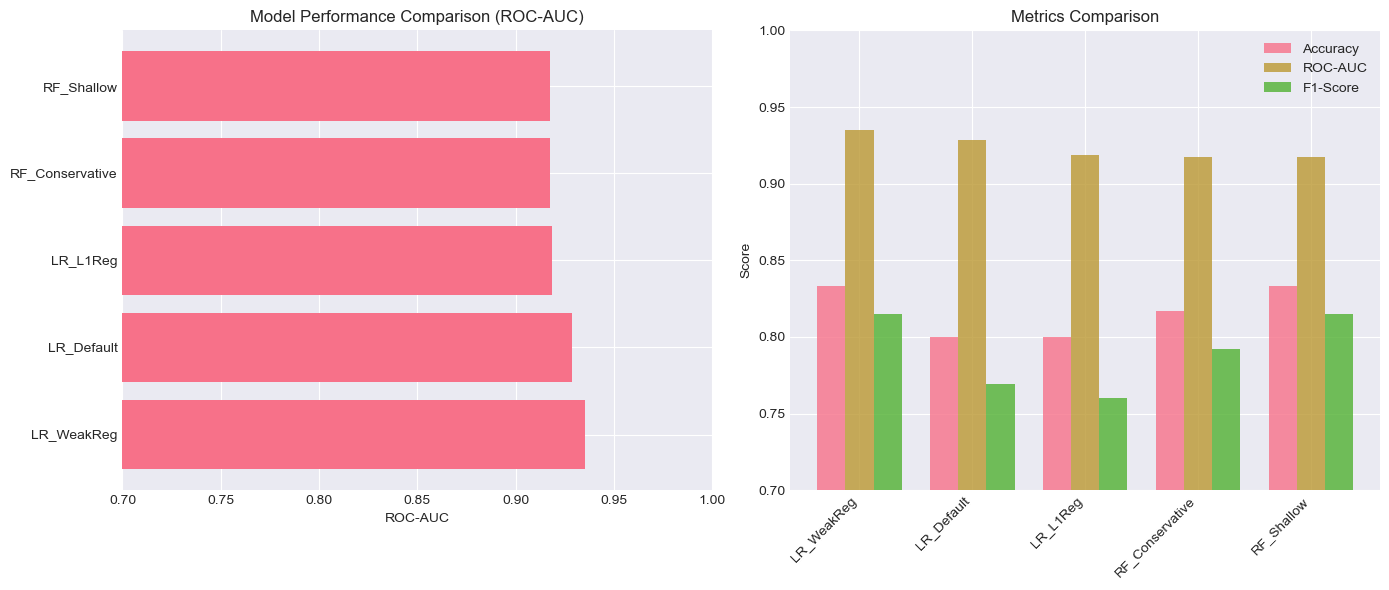


📋 Summary report logged to run: 77df19e004e9420db3ce1970588e9e99

📋 CREATING COMPARISON DASHBOARD


KeyError: ' font-family'

In [ ]:
# ============================================================================
# EXPERIMENT TRACKING WITH MLFLOW
# ============================================================================
!pip install mlflow
import mlflow
import mlflow.sklearn
import mlflow.pyfunc
from mlflow.models.signature import infer_signature
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import tempfile
import os
from datetime import datetime
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, confusion_matrix, 
                           classification_report, roc_curve, auc)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Set visual style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("🔬 MLFLOW EXPERIMENT TRACKING")
print("="*70)

# ============================================================================
# 1. SETUP MLFLOW AND LOAD DATA
# ============================================================================

print("\n📂 SETTING UP MLFLOW")
print("-"*40)

# Set MLflow tracking URI (local by default)
mlflow.set_tracking_uri("file:./mlruns")  # Local file storage
# mlflow.set_tracking_uri("http://localhost:5000")  # Uncomment for MLflow server

# Create or set experiment
experiment_name = "Heart_Disease_Classification"
try:
    experiment_id = mlflow.create_experiment(experiment_name)
except:
    experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id

mlflow.set_experiment(experiment_name)

print(f"✅ Experiment: {experiment_name}")
print(f"📁 Tracking URI: {mlflow.get_tracking_uri()}")

# Load preprocessed data
print("\n📊 LOADING DATA")
print("-"*40)

try:
    df_train = pd.read_csv('heart_disease_train.csv')
    df_test = pd.read_csv('heart_disease_test.csv')
    
    X_train = df_train.drop('heart_disease_binary', axis=1)
    y_train = df_train['heart_disease_binary']
    X_test = df_test.drop('heart_disease_binary', axis=1)
    y_test = df_test['heart_disease_binary']
    
    print(f"✅ Data loaded successfully!")
    print(f"   Training samples: {X_train.shape[0]}, Features: {X_train.shape[1]}")
    print(f"   Test samples: {X_test.shape[0]}")
    
except FileNotFoundError:
    print("⚠️ Preprocessed files not found. Using fresh data...")
    from ucimlrepo import fetch_ucirepo
    heart_disease = fetch_ucirepo(id=45)
    X = heart_disease.data.features
    y = (heart_disease.data.targets['num'] > 0).astype(int)
    
    # Basic preprocessing
    X = X.replace(-9, np.nan)
    X = X.fillna(X.median())
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"✅ Created fresh splits: {X_train.shape[0]} train, {X_test.shape[0]} test")

# ============================================================================
# 2. DEFINE EXPERIMENT RUNS
# ============================================================================

def create_confusion_matrix_plot(y_true, y_pred, model_name):
    """Create and save confusion matrix plot"""
    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    ax.set_title(f'Confusion Matrix - {model_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    
    # Save to temp file
    temp_file = tempfile.NamedTemporaryFile(suffix='.png', delete=False)
    plt.tight_layout()
    plt.savefig(temp_file.name, dpi=150, bbox_inches='tight')
    plt.close()
    return temp_file.name

def create_roc_curve_plot(y_true, y_pred_proba, model_name):
    """Create and save ROC curve plot"""
    fig, ax = plt.subplots(figsize=(8, 6))
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, color='darkorange', lw=2, 
            label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve - {model_name}')
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    
    # Save to temp file
    temp_file = tempfile.NamedTemporaryFile(suffix='.png', delete=False)
    plt.tight_layout()
    plt.savefig(temp_file.name, dpi=150, bbox_inches='tight')
    plt.close()
    return temp_file.name, roc_auc

def create_feature_importance_plot(model, feature_names, model_name):
    """Create and save feature importance plot"""
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[-15:]  # Top 15 features
        
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.barh(range(len(indices)), importances[indices])
        ax.set_yticks(range(len(indices)))
        ax.set_yticklabels([feature_names[i] for i in indices])
        ax.set_xlabel('Feature Importance')
        ax.set_title(f'Feature Importance - {model_name}')
        
        # Save to temp file
        temp_file = tempfile.NamedTemporaryFile(suffix='.png', delete=False)
        plt.tight_layout()
        plt.savefig(temp_file.name, dpi=150, bbox_inches='tight')
        plt.close()
        return temp_file.name
    return None

# ============================================================================
# 3. EXPERIMENT 1: LOGISTIC REGRESSION WITH DIFFERENT PARAMETERS
# ============================================================================

print("\n" + "="*70)
print("🧪 EXPERIMENT 1: LOGISTIC REGRESSION")
print("="*70)

# Define parameter combinations to test
lr_param_combinations = [
    {
        'name': 'LR_Default',
        'C': 1.0,
        'penalty': 'l2',
        'solver': 'lbfgs',
        'max_iter': 1000
    },
    {
        'name': 'LR_StrongReg',
        'C': 0.01,
        'penalty': 'l2',
        'solver': 'lbfgs',
        'max_iter': 1000
    },
    {
        'name': 'LR_L1Reg',
        'C': 1.0,
        'penalty': 'l1',
        'solver': 'liblinear',
        'max_iter': 1000
    },
    {
        'name': 'LR_WeakReg',
        'C': 100.0,
        'penalty': 'l2',
        'solver': 'lbfgs',
        'max_iter': 1000
    }
]

for params in lr_param_combinations:
    run_name = params['name']
    
    with mlflow.start_run(run_name=run_name) as run:
        print(f"\n🏃 Running: {run_name}")
        
        # Log parameters
        mlflow.log_params({
            'model_type': 'LogisticRegression',
            'C': params['C'],
            'penalty': params['penalty'],
            'solver': params['solver'],
            'max_iter': params['max_iter']
        })
        
        # Log dataset info
        mlflow.log_params({
            'train_samples': len(X_train),
            'test_samples': len(X_test),
            'n_features': X_train.shape[1],
            'positive_class_ratio': y_train.mean()
        })
        
        # Train model
        model = LogisticRegression(
            C=params['C'],
            penalty=params['penalty'],
            solver=params['solver'],
            max_iter=params['max_iter'],
            random_state=42
        )
        
        model.fit(X_train, y_train)
        
        # Make predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        # Calculate metrics
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1_score': f1_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_pred_proba)
        }
        
        # Log metrics
        mlflow.log_metrics(metrics)
        
        # Cross-validation scores
        cv_scores = cross_val_score(
            model, X_train, y_train,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='roc_auc'
        )
        mlflow.log_metrics({
            'cv_roc_auc_mean': cv_scores.mean(),
            'cv_roc_auc_std': cv_scores.std()
        })
        
        # Create and log plots
        cm_plot_path = create_confusion_matrix_plot(y_test, y_pred, run_name)
        roc_plot_path, roc_auc = create_roc_curve_plot(y_test, y_pred_proba, run_name)
        
        mlflow.log_artifact(cm_plot_path, "plots")
        mlflow.log_artifact(roc_plot_path, "plots")
        
        # Log classification report
        report = classification_report(y_test, y_pred, output_dict=True)
        with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
            json.dump(report, f, indent=2)
            mlflow.log_artifact(f.name, "reports")
        
        # Log model
        signature = infer_signature(X_train, model.predict(X_train))
        mlflow.sklearn.log_model(
            model,
            "model",
            signature=signature,
            input_example=X_train.iloc[:5]
        )
        
        # Add tags
        mlflow.set_tags({
            'project': 'heart_disease',
            'team': 'student_project',
            'model_family': 'linear_models',
            'iteration': 'v1'
        })
        
        # Cleanup temp files
        os.unlink(cm_plot_path)
        os.unlink(roc_plot_path)
        
        print(f"   ✅ Logged: Accuracy={metrics['accuracy']:.3f}, ROC-AUC={metrics['roc_auc']:.3f}")
        print(f"   📊 Run ID: {run.info.run_id}")

# ============================================================================
# 4. EXPERIMENT 2: RANDOM FOREST WITH DIFFERENT PARAMETERS
# ============================================================================

print("\n" + "="*70)
print("🧪 EXPERIMENT 2: RANDOM FOREST")
print("="*70)

# Define parameter combinations to test
rf_param_combinations = [
    {
        'name': 'RF_Default',
        'n_estimators': 100,
        'max_depth': None,
        'min_samples_split': 2,
        'min_samples_leaf': 1,
        'max_features': 'sqrt'
    },
    {
        'name': 'RF_Shallow',
        'n_estimators': 100,
        'max_depth': 10,
        'min_samples_split': 5,
        'min_samples_leaf': 4,
        'max_features': 'sqrt'
    },
    {
        'name': 'RF_Deep',
        'n_estimators': 300,
        'max_depth': None,
        'min_samples_split': 2,
        'min_samples_leaf': 1,
        'max_features': 'log2'
    },
    {
        'name': 'RF_Conservative',
        'n_estimators': 200,
        'max_depth': 20,
        'min_samples_split': 10,
        'min_samples_leaf': 2,
        'max_features': 'sqrt'
    }
]

for params in rf_param_combinations:
    run_name = params['name']
    
    with mlflow.start_run(run_name=run_name) as run:
        print(f"\n🏃 Running: {run_name}")
        
        # Log parameters
        mlflow.log_params({
            'model_type': 'RandomForest',
            'n_estimators': params['n_estimators'],
            'max_depth': params['max_depth'],
            'min_samples_split': params['min_samples_split'],
            'min_samples_leaf': params['min_samples_leaf'],
            'max_features': params['max_features']
        })
        
        # Train model
        model = RandomForestClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_split=params['min_samples_split'],
            min_samples_leaf=params['min_samples_leaf'],
            max_features=params['max_features'],
            random_state=42,
            n_jobs=-1
        )
        
        model.fit(X_train, y_train)
        
        # Make predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        # Calculate metrics
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1_score': f1_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_pred_proba)
        }
        
        # Log metrics
        mlflow.log_metrics(metrics)
        
        # Cross-validation scores
        cv_scores = cross_val_score(
            model, X_train, y_train,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='roc_auc'
        )
        mlflow.log_metrics({
            'cv_roc_auc_mean': cv_scores.mean(),
            'cv_roc_auc_std': cv_scores.std()
        })
        
        # Create and log plots
        cm_plot_path = create_confusion_matrix_plot(y_test, y_pred, run_name)
        roc_plot_path, roc_auc = create_roc_curve_plot(y_test, y_pred_proba, run_name)
        
        mlflow.log_artifact(cm_plot_path, "plots")
        mlflow.log_artifact(roc_plot_path, "plots")
        
        # Feature importance plot
        fi_plot_path = create_feature_importance_plot(model, X_train.columns, run_name)
        if fi_plot_path:
            mlflow.log_artifact(fi_plot_path, "plots")
        
        # Log feature importance as JSON
        if hasattr(model, 'feature_importances_'):
            fi_dict = dict(zip(X_train.columns, model.feature_importances_))
            fi_sorted = dict(sorted(fi_dict.items(), key=lambda x: x[1], reverse=True)[:10])
            with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
                json.dump(fi_sorted, f, indent=2)
                mlflow.log_artifact(f.name, "feature_importance")
        
        # Log classification report
        report = classification_report(y_test, y_pred, output_dict=True)
        with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
            json.dump(report, f, indent=2)
            mlflow.log_artifact(f.name, "reports")
        
        # Log model
        signature = infer_signature(X_train, model.predict(X_train))
        mlflow.sklearn.log_model(
            model,
            "model",
            signature=signature,
            input_example=X_train.iloc[:5]
        )
        
        # Add tags
        mlflow.set_tags({
            'project': 'heart_disease',
            'team': 'student_project',
            'model_family': 'ensemble_models',
            'iteration': 'v1'
        })
        
        # Cleanup temp files
        os.unlink(cm_plot_path)
        os.unlink(roc_plot_path)
        if fi_plot_path:
            os.unlink(fi_plot_path)
        
        print(f"   ✅ Logged: Accuracy={metrics['accuracy']:.3f}, ROC-AUC={metrics['roc_auc']:.3f}")
        print(f"   📊 Run ID: {run.info.run_id}")

# ============================================================================
# 5. EXPERIMENT 3: HYPERPARAMETER TUNING WITH GRID SEARCH
# ============================================================================

print("\n" + "="*70)
print("🧪 EXPERIMENT 3: GRID SEARCH TUNING")
print("="*70)

from sklearn.model_selection import GridSearchCV

with mlflow.start_run(run_name="GridSearch_RandomForest") as run:
    print("\n🏃 Running: GridSearch_RandomForest")
    
    # Define parameter grid
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    
    # Log search space
    mlflow.log_params({
        'search_space': str(param_grid),
        'cv_folds': 5,
        'scoring': 'roc_auc'
    })
    
    # Perform grid search
    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train, y_train)
    
    # Log best parameters
    best_params = grid_search.best_params_
    mlflow.log_params(best_params)
    
    # Get best model
    best_model = grid_search.best_estimator_
    
    # Make predictions
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'best_cv_score': grid_search.best_score_
    }
    
    # Log metrics
    mlflow.log_metrics(metrics)
    
    # Create and log plots
    cm_plot_path = create_confusion_matrix_plot(y_test, y_pred, "GridSearch_RF")
    roc_plot_path, roc_auc = create_roc_curve_plot(y_test, y_pred_proba, "GridSearch_RF")
    
    mlflow.log_artifact(cm_plot_path, "plots")
    mlflow.log_artifact(roc_plot_path, "plots")
    
    # Log grid search results
    results_df = pd.DataFrame(grid_search.cv_results_)
    with tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False) as f:
        results_df.to_csv(f.name, index=False)
        mlflow.log_artifact(f.name, "grid_search_results")
    
    # Log model
    signature = infer_signature(X_train, best_model.predict(X_train))
    mlflow.sklearn.log_model(
        best_model,
        "best_model",
        signature=signature,
        input_example=X_train.iloc[:5]
    )
    
    # Add tags
    mlflow.set_tags({
        'project': 'heart_disease',
        'team': 'student_project',
        'optimization': 'grid_search',
        'best_model': 'RandomForest'
    })
    
    # Cleanup temp files
    os.unlink(cm_plot_path)
    os.unlink(roc_plot_path)
    
    print(f"   ✅ Best params: {best_params}")
    print(f"   📈 Best CV score: {grid_search.best_score_:.4f}")
    print(f"   🎯 Test ROC-AUC: {metrics['roc_auc']:.4f}")
    print(f"   📊 Run ID: {run.info.run_id}")

# ============================================================================
# 6. GENERATE EXPERIMENT SUMMARY REPORT
# ============================================================================

print("\n" + "="*70)
print("📊 EXPERIMENT SUMMARY")
print("="*70)

# Query MLflow for experiment results
from mlflow.tracking import MlflowClient

client = MlflowClient()
experiment = client.get_experiment_by_name(experiment_name)

if experiment:
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        order_by=["metrics.roc_auc DESC"]
    )
    
    print(f"\n📈 TOP 5 RUNS BY ROC-AUC:")
    print("-"*80)
    print(f"{'Run Name':25s} {'Model Type':15s} {'ROC-AUC':8s} {'Accuracy':10s} {'F1-Score':10s} {'Run ID':15s}")
    print("-"*80)
    
    summary_data = []
    for i, run in enumerate(runs[:5]):
        run_name = run.data.tags.get('mlflow.runName', run.info.run_id[:8])
        model_type = run.data.tags.get('model_family', 'Unknown')
        roc_auc = run.data.metrics.get('roc_auc', 0)
        accuracy = run.data.metrics.get('accuracy', 0)
        f1_score_val = run.data.metrics.get('f1_score', 0)
        
        print(f"{run_name:25s} {model_type:15s} {roc_auc:8.4f} {accuracy:10.4f} {f1_score_val:10.4f} {run.info.run_id[:15]:15s}")
        summary_data.append({
            'run_name': run_name,
            'model_type': model_type,
            'roc_auc': roc_auc,
            'accuracy': accuracy,
            'f1_score': f1_score_val,
            'run_id': run.info.run_id
        })
    
    # Create summary visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # ROC-AUC comparison
    runs_data = pd.DataFrame(summary_data)
    if not runs_data.empty:
        axes[0].barh(range(len(runs_data)), runs_data['roc_auc'])
        axes[0].set_yticks(range(len(runs_data)))
        axes[0].set_yticklabels(runs_data['run_name'])
        axes[0].set_xlabel('ROC-AUC')
        axes[0].set_title('Model Performance Comparison (ROC-AUC)')
        axes[0].set_xlim([0.7, 1.0])
        
        # Metric comparison
        x = np.arange(len(runs_data))
        width = 0.25
        axes[1].bar(x - width, runs_data['accuracy'], width, label='Accuracy', alpha=0.8)
        axes[1].bar(x, runs_data['roc_auc'], width, label='ROC-AUC', alpha=0.8)
        axes[1].bar(x + width, runs_data['f1_score'], width, label='F1-Score', alpha=0.8)
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(runs_data['run_name'], rotation=45, ha='right')
        axes[1].set_ylabel('Score')
        axes[1].set_title('Metrics Comparison')
        axes[1].legend()
        axes[1].set_ylim([0.7, 1.0])
    
    plt.tight_layout()
    plt.savefig('experiment_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Log summary to MLflow
    with mlflow.start_run(run_name="Experiment_Summary") as summary_run:
        mlflow.log_artifact('experiment_summary.png', "summary")
        
        # Create summary report
        summary_report = {
            'experiment_name': experiment_name,
            'total_runs': len(runs),
            'best_run': summary_data[0] if summary_data else {},
            'summary_generated': datetime.now().isoformat()
        }
        
        with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
            json.dump(summary_report, f, indent=2)
            mlflow.log_artifact(f.name, "summary")
        
        mlflow.set_tags({
            'project': 'heart_disease',
            'report_type': 'experiment_summary',
            'team': 'student_project'
        })
        
        print(f"\n📋 Summary report logged to run: {summary_run.info.run_id}")
    
    # Cleanup
    if os.path.exists('experiment_summary.png'):
        os.remove('experiment_summary.png')

# ============================================================================
# 7. CREATE COMPARISON DASHBOARD (OPTIONAL)
# ============================================================================

print("\n" + "="*70)
print("📋 CREATING COMPARISON DASHBOARD")
print("="*70)

# Create a simple HTML dashboard
html_template = """
<!DOCTYPE html>
<html>
<head>
    <title>Heart Disease Classification - Experiment Dashboard</title>
    <style>
        body { font-family: Arial, sans-serif; margin: 40px; }
        .header { background: #2c3e50; color: white; padding: 20px; border-radius: 5px; }
        .model-card { border: 1px solid #ddd; border-radius: 5px; padding: 20px; margin: 20px 0; }
        .metric { display: inline-block; margin-right: 30px; }
        .metric-value { font-size: 24px; font-weight: bold; }
        .best { background-color: #e8f5e8; border-left: 5px solid #2ecc71; }
    </style>
</head>
<body>
    <div class="header">
        <h1>🧠 Heart Disease Classification Experiments</h1>
        <p>MLflow Experiment Tracking Dashboard</p>
    </div>
    
    <h2>📊 Experiment Summary</h2>
    <p><strong>Experiment Name:</strong> {experiment_name}</p>
    <p><strong>Total Runs:</strong> {total_runs}</p>
    <p><strong>Best Model:</strong> {best_model_name} (ROC-AUC: {best_roc_auc:.4f})</p>
    
    <h2>🏆 Top Performing Models</h2>
    {model_cards}
    
    <h2>📈 How to View in MLflow UI</h2>
    <ol>
        <li>Install MLflow: <code>pip install mlflow</code></li>
        <li>Start MLflow UI: <code>mlflow ui</code></li>
        <li>Open browser: <a href="http://localhost:5000">http://localhost:5000</a></li>
        <li>Select experiment: "{experiment_name}"</li>
    </ol>
    
    <footer>
        <p>Generated on: {generation_time}</p>
    </footer>
</body>
</html>
"""

# Create model cards HTML
model_cards_html = ""
if 'summary_data' in locals() and summary_data:
    for i, model in enumerate(summary_data):
        best_class = "best" if i == 0 else ""
        model_cards_html += f"""
        <div class="model-card {best_class}">
            <h3>{model['run_name']} ({model['model_type']})</h3>
            <div class="metric"><span class="metric-label">ROC-AUC:</span><br><span class="metric-value">{model['roc_auc']:.4f}</span></div>
            <div class="metric"><span class="metric-label">Accuracy:</span><br><span class="metric-value">{model['accuracy']:.4f}</span></div>
            <div class="metric"><span class="metric-label">F1-Score:</span><br><span class="metric-value">{model['f1_score']:.4f}</span></div>
            <p><small>Run ID: {model['run_id'][:15]}...</small></p>
        </div>
        """

# Generate final HTML
html_content = html_template.format(
    experiment_name=experiment_name,
    total_runs=len(runs) if 'runs' in locals() else 0,
    best_model_name=summary_data[0]['run_name'] if summary_data else "N/A",
    best_roc_auc=summary_data[0]['roc_auc'] if summary_data else 0,
    model_cards=model_cards_html,
    generation_time=datetime.now().strftime("%Y-%m-%d %H:%M:%S")
)

# Save HTML dashboard
with open('experiment_dashboard.html', 'w') as f:
    f.write(html_content)

print(f"✅ Dashboard created: experiment_dashboard.html")
print(f"📊 Total experiments tracked: {len(runs) if 'runs' in locals() else 'N/A'}")

# ============================================================================
# 8. FINAL INSTRUCTIONS
# ============================================================================

print("\n" + "="*70)
print("🚀 MLFLOW EXPERIMENT TRACKING COMPLETED!")
print("="*70)

print("""
📁  EXPERIMENTS ARE TRACKED IN:
• Local directory: ./mlruns/
• HTML Dashboard: experiment_dashboard.html

🎯 TO VIEW RESULTS IN MLFLOW UI:
1. Open terminal in this directory
2. Run: mlflow ui
3. Open browser to: http://localhost:5000
4. Select 'Heart_Disease_Classification' experiment

📊 WHAT WAS LOGGED FOR EACH RUN:
• Parameters (model hyperparameters, dataset info)
• Metrics (accuracy, precision, recall, F1, ROC-AUC)
• Artifacts (plots, reports, models)
• Tags (project metadata)

🔍 TO QUERY RESULTS PROGRAMMATICALLY:
from mlflow.tracking import MlflowClient
client = MlflowClient()
runs = client.search_runs(experiment_ids=[...])
""")

print(f"\n✅ Experiment tracking completed successfully!")
print(f"📈 View results at: {mlflow.get_tracking_uri()}")